# Decision Tree Classification on NHANES 2021–2023
## Socioeconomic Determinants of Health Insurance Coverage

This section builds a **Decision Tree classifier** to predict **health insurance type** 
based on socioeconomic variables using the cleaned NHANES 2021–2023 dataset.

We focus on:

1. Data loading and preprocessing (age ≥ 18).
2. Building a Decision Tree to predict `insurance_type`.
3. Evaluating model performance (Accuracy, Precision, Recall, F1, ROC-AUC).
4. Visualizing the decision tree and feature importance.
5. Connecting results to the association rules (FP-growth) analysis.


In [47]:
# Basic utilities
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

FIG_DIR = "../reports/figures"

os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    filepath = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(filepath, dpi=300, bbox_inches="tight")

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.preprocessing import LabelEncoder


In [48]:
# Load cleaned NHANES dataset
# Make sure nhanes_clean.csv is in the same folder as this notebook
df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

print("Shape of raw cleaned dataset:", df.shape)
df.head()


Shape of raw cleaned dataset: (8153, 24)


,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type,marital_status,household_size,is_employed
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,Unknown,45.0,9.5,No,Insured,Yes,Private only,Married / living with partner,4.0,Yes
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,Unknown,45.0,9.0,No,Insured,Unknown,Both,Married / living with partner,2.0,Yes
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only,Married / living with partner,7.0,Yes
3,130384.0,43.0,Male,Mexican American,9-11th grade,0.63,87.5,176.0,28.3,120.0,...,Unknown,60.0,7.5,No,Not insured,Unknown,Uninsured,Never married,2.0,Yes
4,130385.0,65.0,Female,Non-Hispanic White,High school/GED,5.00,72.7,159.2,28.7,127.0,...,Unknown,60.0,8.0,No,Insured,No,Public only,Married / living with partner,2.0,No


In [49]:
# Keep adults (age >= 18), consistent with FP-mining step
df_adult = df[df["age"] >= 18].copy()
print("Shape after filtering adults (age >= 18):", df_adult.shape)

# Check missing values for key variables
cols_of_interest = ['age',
    'gender',
    'race',
    'education',
    'income_poverty_ratio',
    'marital_status',
    'household_size',
    'is_employed',
    # new features
    'smoking_current',
    'diabetes_self_report',
    'bmi',
    'sbp',
    'dbp',
    'a1c',
    'sleep_hours', "insurance_type"]

df_adult[cols_of_interest].isna().sum()


Shape after filtering adults (age >= 18): (8153, 24)


age                     0
gender                  0
race                    0
education               0
income_poverty_ratio    0
marital_status          0
household_size          0
is_employed             0
smoking_current         0
diabetes_self_report    0
bmi                     0
sbp                     0
dbp                     0
a1c                     0
sleep_hours             0
insurance_type          0
dtype: int64

In [50]:
# Drop rows with missing values in key columns
dt_data = df_adult[cols_of_interest].dropna().copy()
print("Shape after dropping NA in key columns:", dt_data.shape)

# Define features (X) and target (y)
feature_cols = ['age',
    'gender',
    'race',
    'education',
    'income_poverty_ratio',
    'marital_status',
    'household_size',
    'is_employed',
    # new features
    'smoking_current',
    'diabetes_self_report',
    'bmi',
    'sbp',
    'dbp',
    'a1c',
    'sleep_hours']
target_col = "insurance_type"

X = dt_data[feature_cols].copy()
y = dt_data[target_col].copy()


Shape after dropping NA in key columns: (8153, 16)


In [51]:
# Identify categorical features
categorical_cols = ['gender',
    'race',
    'education',
    'marital_status',
    'is_employed',
    'smoking_current',
    'diabetes_self_report']
label_encoders = {}

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target variable (insurance_type)
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y.astype(str))

print("Encoded classes for insurance_type:", target_encoder.classes_)


Encoded classes for insurance_type: ['Both' 'Private only' 'Public only' 'Uninsured' 'Unknown']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded 
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (6522, 15) Test size: (1631, 15)


In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold (分层抽样)
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
dt_cv = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

cv_scores = cross_val_score(
    dt_cv, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring="accuracy"
)

print("Decision Tree (Stratified) 10-fold CV Accuracy:")
print("Scores for each fold:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

# GridSearchCV for Estimator Optimization

param_grid_dt = {
    'criterion': ['gini', 'entropy'],  
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'splitter': ['best', 'random']
}
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# Stratified K-Fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Base DT (the estimator we will optimize)
dt_model = DecisionTreeClassifier(random_state=42)

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=cv,                 # ← StratifiedKFold
    scoring="accuracy",
    n_jobs=-1,
)

grid_dt.fit(X_train, y_train)

print("Best CV accuracy:", grid_dt.best_score_)
print("\nBest parameters:")
for k, v in grid_dt.best_params_.items():
    print(f"  {k}: {v}")




Decision Tree (Stratified) 10-fold CV Accuracy:
Scores for each fold: [0.62480858 0.62787136 0.6196319  0.62269939 0.62576687 0.64723926
 0.62730061 0.61656442 0.59969325 0.62423313]
Mean CV accuracy: 0.6235808773100086
Std CV accuracy: 0.011112587510663768
Best CV accuracy: 0.6245008878324674

Best parameters:
  criterion: entropy
  max_depth: 5
  min_samples_leaf: 10
  min_samples_split: 50
  splitter: best


In [54]:
dt = DecisionTreeClassifier(
    criterion="gini",      
    max_depth=5,           
    min_samples_split=50,  
    min_samples_leaf=20,   
    class_weight=None,     
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

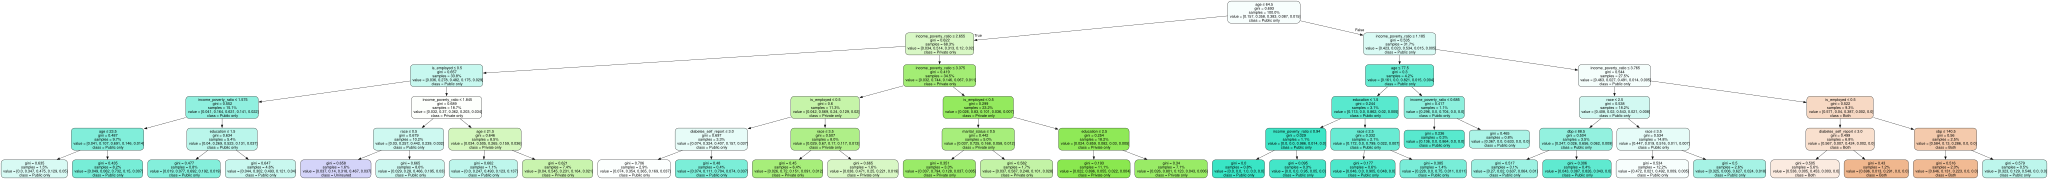

Saved full decision tree to: ../reports/figures/dt_full_tree.png


In [55]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,                                  
    out_file=None,
    feature_names=X.columns,              # ["age", "gender", "race", "education", "income_poverty_ratio"]
    class_names=target_encoder.classes_,  # ['Both', 'Private only', ...]
    filled=True,                          
    rounded=True,                         
    proportion=True,                      
    special_characters=True
)

graph = graphviz.Source(dot_data)
display(graph)
graph.render(
    filename="dt_full_tree",
    directory=FIG_DIR,
    format="png",
    cleanup=True
)
print("Saved full decision tree to:", os.path.join(FIG_DIR, "dt_full_tree.png"))

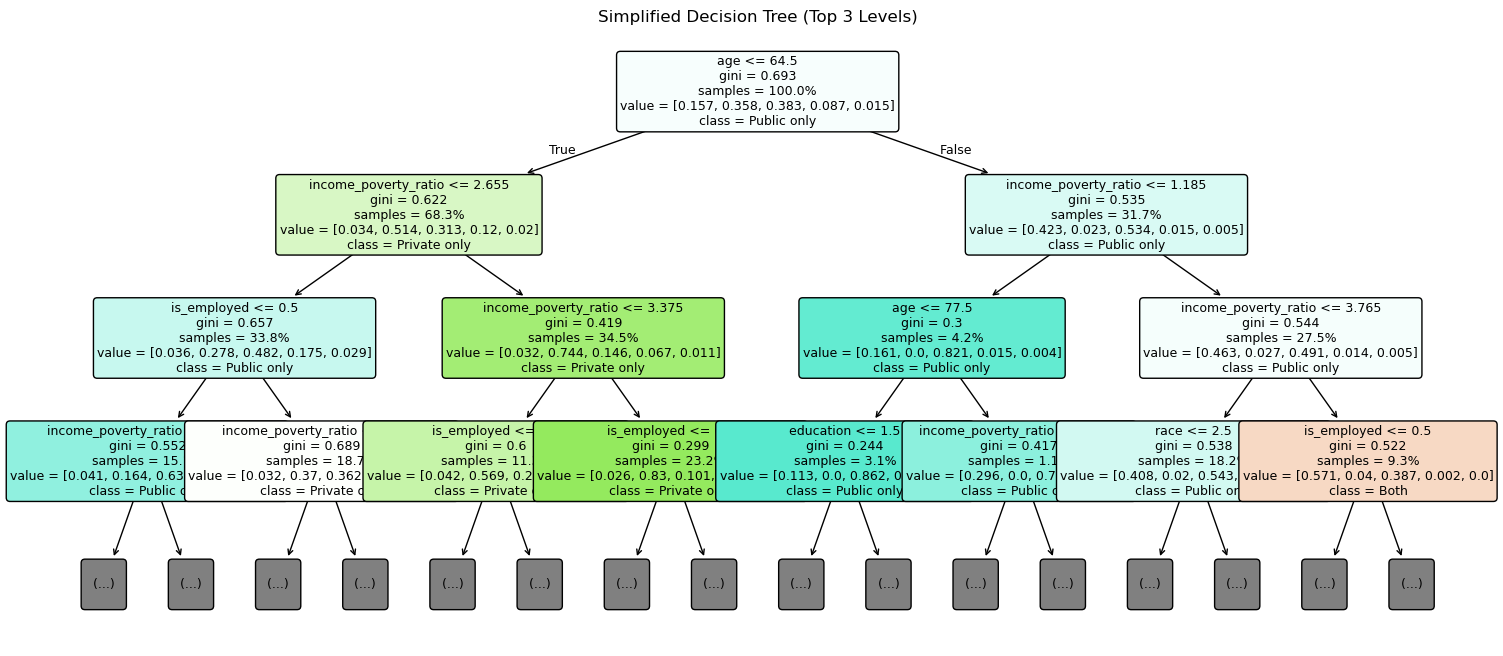

In [56]:
from sklearn import tree
fig = plt.figure(figsize=(18, 8))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,       
    proportion=True,
    fontsize=9
)
plt.title("Simplified Decision Tree (Top 3 Levels)")
save_fig(fig, "dt_tree_top3_levels") 
plt.show()


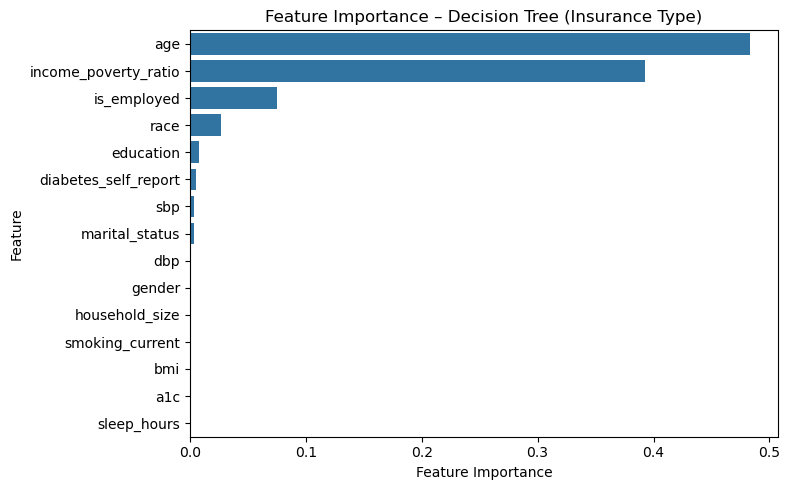

age                     0.483492
income_poverty_ratio    0.393042
is_employed             0.074902
race                    0.026475
education               0.008101
diabetes_self_report    0.005548
sbp                     0.003822
marital_status          0.003241
dbp                     0.001377
gender                  0.000000
household_size          0.000000
smoking_current         0.000000
bmi                     0.000000
a1c                     0.000000
sleep_hours             0.000000
dtype: float64

In [57]:
import seaborn as sns

importances = dt.feature_importances_
feature_cols = ['age',
    'gender',
    'race',
    'education',
    'income_poverty_ratio',
    'marital_status',
    'household_size',
    'is_employed',
    # new features
    'smoking_current',
    'diabetes_self_report',
    'bmi',
    'sbp',
    'dbp',
    'a1c',
    'sleep_hours']

feat_imp = (
    pd.Series(importances, index=feature_cols)
    .sort_values(ascending=False)
)

fig = plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance – Decision Tree (Insurance Type)")
save_fig(fig, "dt_feature_importance") 
plt.tight_layout()
plt.show()

feat_imp


## Decision Tree 2: SES + Lifestyle + Insurance → Diabetes Risk

This section builds a second Decision Tree classifier to predict **diabetes risk**  
(using a combined label from self-reported diabetes or A1C ≥ 6.5), based on
socio-economic status, lifestyle, and insurance coverage.

We focus on:

1. Constructing a diabetes risk label (self-report = *Yes* or A1C ≥ 6.5).
2. Training a Decision Tree using SES + lifestyle + insurance features.
3. Evaluating model performance (Accuracy, Precision, Recall, F1).
4. Visualizing the decision tree, confusion matrix, and feature importance.


In [58]:
# 1. 只取 age ≥ 18 的 adult
nhanes_clean_adult = df[df["age"] >= 18].copy()
print("Adult sample size:", nhanes_clean_adult.shape)

# 2. 构建 diabetes_risk 标记（方式 C）
#    1 = 已自报糖尿病 或 当前 A1C ≥ 6.5
#    0 = 其他
nhanes_clean_adult["diabetes_risk"] = np.where(
    (nhanes_clean_adult["diabetes_self_report"] == "Yes") |
    ((nhanes_clean_adult["a1c"].notna()) & (nhanes_clean_adult["a1c"] >= 6.5)),
    1,
    0
)

print(
    nhanes_clean_adult["diabetes_risk"]
    .value_counts(normalize=True)
    .rename("diabetes_risk proportion")
)

# 2.5 重新做 A1C / BMI / 睡眠的离散化（一定要在 adult 上重建）
nhanes_clean_adult["a1c_bin"] = pd.cut(
    nhanes_clean_adult["a1c"],
    bins=[0, 5.7, 6.5, np.inf],
    labels=["Normal", "Prediabetes", "Diabetes"]
)

nhanes_clean_adult["bmi_bin"] = pd.cut(
    nhanes_clean_adult["bmi"],
    bins=[0, 25, 30, np.inf],
    labels=["Normal", "Overweight", "Obesity"]
)

nhanes_clean_adult["sleep_bin"] = pd.cut(
    nhanes_clean_adult["sleep_hours"],
    bins=[0, 6, 8, np.inf],
    labels=["Short (<6h)", "Normal (6-8h)", "Long (>8h)"]
)

Adult sample size: (8153, 24)
diabetes_risk
0    0.849749
1    0.150251
Name: diabetes_risk proportion, dtype: float64


In [59]:
# 3. 特征列：SES + Lifestyle + Insurance
#    注意：不要把 a1c / diabetes_self_report 放进 X
diabetes_feature_cols = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "bmi_bin",
    "sleep_bin",
    "smoking_current",
    "insurance_type",
]

target_col_diabetes = "diabetes_risk"
diabetes_cols = diabetes_feature_cols + [target_col_diabetes]

df_diabetes_raw = nhanes_clean_adult[diabetes_cols].copy()
print("Shape before dropping NA:", df_diabetes_raw.shape)
print("Missing values in each column:")
print(df_diabetes_raw.isna().sum())

# 4. 简单策略：把有缺失的样本删掉
df_diabetes = df_diabetes_raw.dropna()
print("Shape after dropping NA:", df_diabetes.shape)

# 5. 拆分 X / y
X_diabetes = df_diabetes[diabetes_feature_cols].copy()
y_diabetes = df_diabetes[target_col_diabetes].copy()

Shape before dropping NA: (8153, 10)
Missing values in each column:
age                     0
gender                  0
race                    0
education               0
income_poverty_ratio    0
bmi_bin                 0
sleep_bin               0
smoking_current         0
insurance_type          0
diabetes_risk           0
dtype: int64
Shape after dropping NA: (8153, 10)


In [60]:
# -------------------------------------------------------------
# 4. 对分类变量做 one-hot 编码
#    （也可以改成跟第一棵树完全一样的编码方式）
# -------------------------------------------------------------
categorical_cols_diabetes = [
    "gender",
    "race",
    "education",
    "bmi_bin",
    "sleep_bin",
    "smoking_current",
    "insurance_type",
]

X_diabetes_encoded = pd.get_dummies(
    X_diabetes,
    columns=categorical_cols_diabetes,
    drop_first=False,  # 保留所有类别，方便解释
)

print("Encoded feature shape:", X_diabetes_encoded.shape)

# 训练 / 测试集划分（按标签分层抽样）
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes_encoded,
    y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes,
)

X_train_d.shape, X_test_d.shape


Encoded feature shape: (8153, 32)


((6522, 32), (1631, 32))

In [61]:
dt_cv_diabetes = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)

cv_scores_d = cross_val_score(
    dt_cv_diabetes,
    X_train_d,
    y_train_d,
    cv=10,
    scoring="accuracy",
)

print("Decision Tree (Diabetes risk) 10-fold CV Accuracy:")
print("Each fold:", cv_scores_d)
print("Mean ± std:", cv_scores_d.mean(), "±", cv_scores_d.std())


Decision Tree (Diabetes risk) 10-fold CV Accuracy:
Each fold: [0.86064319 0.85298622 0.85429448 0.83895706 0.85276074 0.84969325
 0.84815951 0.86042945 0.84815951 0.85889571]
Mean ± std: 0.8524979096008043 ± 0.006344967065167108


In [62]:
dt_diabetes = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)

dt_diabetes.fit(X_train_d, y_train_d)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

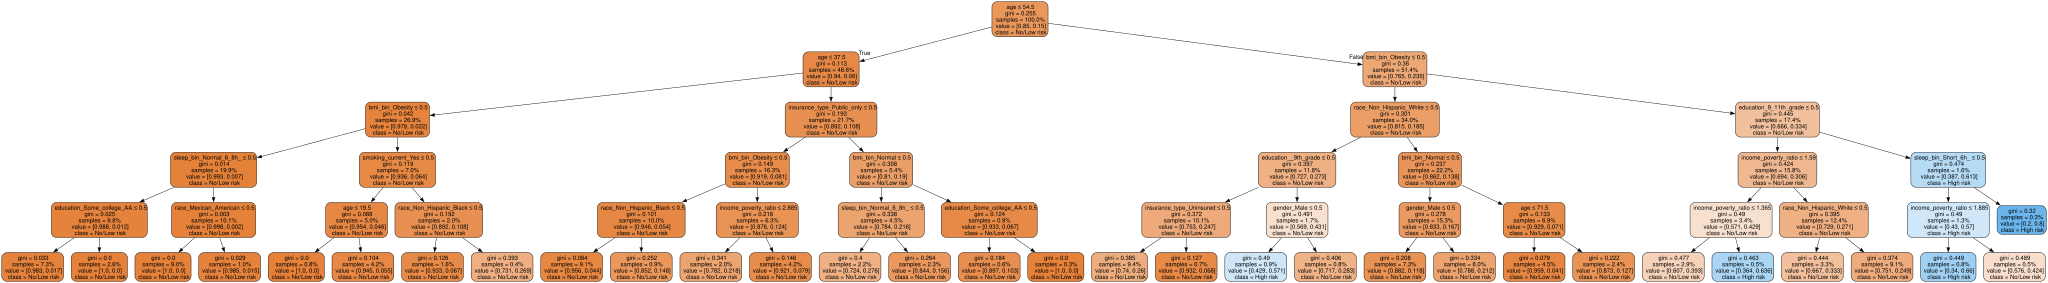

In [63]:
# -------------------------------------------------------------
# 7. 用 graphviz 画出决策树（自动修复特征名），并保存为 PNG
# -------------------------------------------------------------
import re
import graphviz
import os

def make_safe(name):
    """清理列名，替换掉 Graphviz 不支持的字符"""
    return re.sub(r'[^0-9a-zA-Z_]+', '_', str(name))

# 创建安全列名
safe_feature_names = [make_safe(col) for col in X_diabetes_encoded.columns]

# 生成 dot 数据
dot_data_d = export_graphviz(
    dt_diabetes,
    out_file=None,
    feature_names=safe_feature_names,       # ← 使用安全名称
    class_names=["No/Low risk", "High risk"],
    filled=True,
    rounded=True,
    proportion=True,
    special_characters=True,
)

# 在 Notebook 中显示
graph_d = graphviz.Source(dot_data_d)
graph_d

In [64]:
tree_filename = "dt2_diabetes_tree"
output_path = os.path.join(FIG_DIR, tree_filename)

graph_d.render(
    filename=tree_filename,
    directory=FIG_DIR,
    format="png",
    cleanup=True
)

print("Saved decision tree 2 to:", output_path + ".png")

Saved decision tree 2 to: ../reports/figures/dt2_diabetes_tree.png


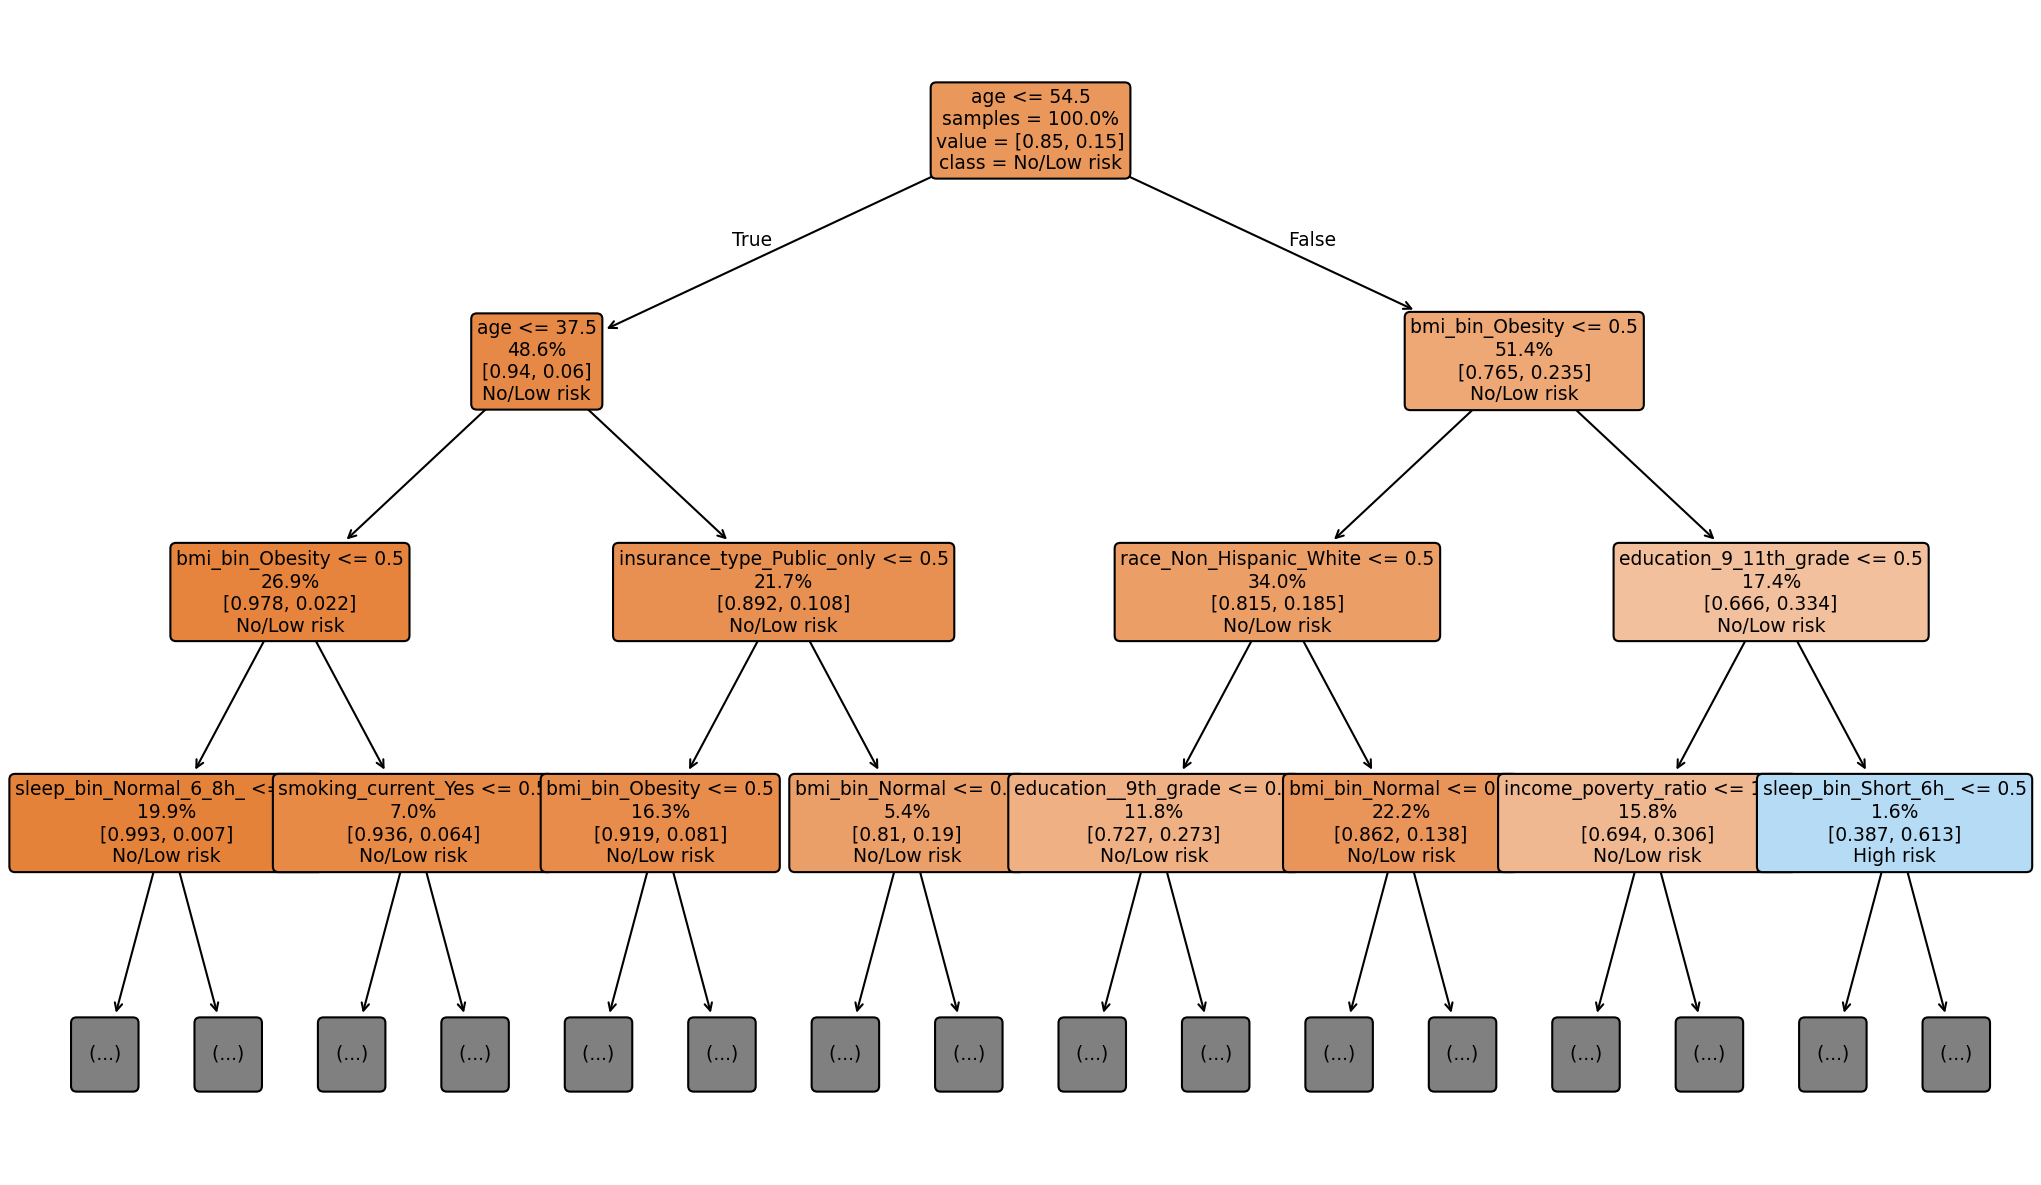

Saved PPT-style tree to: ../reports/figures/dt2_diabetes_tree_ppt.png


In [65]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os

# 1. 统一设置：白底、适合投影
plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white"
})

fig, ax = plt.subplots(figsize=(14, 8), dpi=150)  # 尺寸适合 PPT 宽屏

plot_tree(
    dt_diabetes,
    feature_names=safe_feature_names,
    class_names=["No/Low risk", "High risk"],
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3,       # 只展示前 3 层，避免太密
    impurity=False,    # 去掉 gini，让节点信息更简洁
    label="root",      # 根节点标注；想更干净可改成 "none"
    fontsize=9         # 字体大小，PPT 上比较清晰
)

ax.set_axis_off()      # 去掉坐标轴边框
plt.tight_layout()

out_path = os.path.join(FIG_DIR, "dt2_diabetes_tree_ppt.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")  # 300dpi 适合打印和 PPT
plt.show()

print("Saved PPT-style tree to:", out_path)


Age                           0.455596
BMI (bmi_bin)                 0.185852
Education                     0.100126
Race / ethnicity              0.094994
Income-poverty ratio          0.071273
Insurance type                0.037581
Gender                        0.036138
Sleep duration (sleep_bin)    0.015596
Smoking status                0.002843
dtype: float64


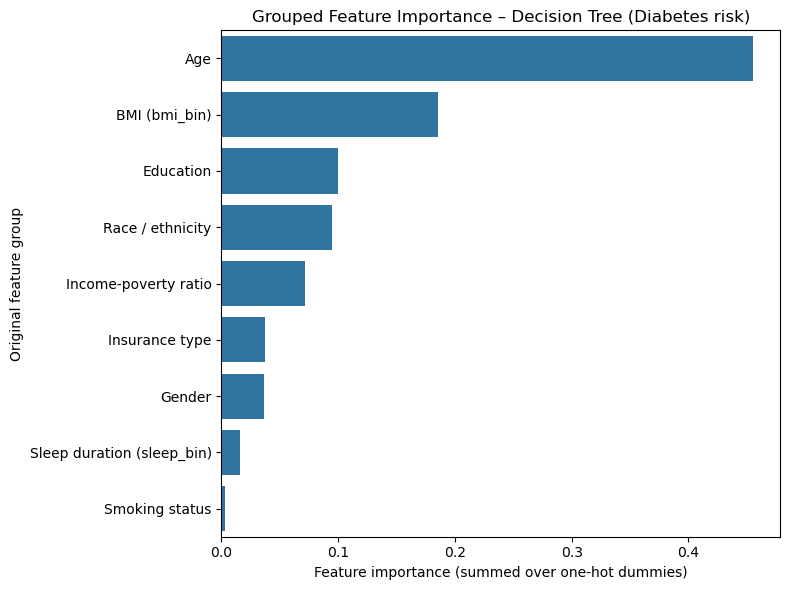

Saved grouped feature importance to: ../reports/figures/dt2_feature_importance_grouped.png


In [66]:
# 1) 先得到每一列 dummy 的 importance
feat_series = pd.Series(
    dt_diabetes.feature_importances_,
    index=X_diabetes_encoded.columns
)

# 2) 定义“原始变量 → dummy 列”的分组规则
group_map = {
    "Age": [col for col in X_diabetes_encoded.columns if col == "age"],
    "Income-poverty ratio": [col for col in X_diabetes_encoded.columns if col == "income_poverty_ratio"],
    "BMI (bmi_bin)": [col for col in X_diabetes_encoded.columns if col.startswith("bmi_bin_")],
    "Sleep duration (sleep_bin)": [col for col in X_diabetes_encoded.columns if col.startswith("sleep_bin_")],
    "Gender": [col for col in X_diabetes_encoded.columns if col.startswith("gender_")],
    "Race / ethnicity": [col for col in X_diabetes_encoded.columns if col.startswith("race_")],
    "Education": [col for col in X_diabetes_encoded.columns if col.startswith("education_")],
    "Smoking status": [col for col in X_diabetes_encoded.columns if col.startswith("smoking_current_")],
    "Insurance type": [col for col in X_diabetes_encoded.columns if col.startswith("insurance_type_")],
}

# 3) 对每一组的 importance 做求和
group_imp = {}
for group_name, cols in group_map.items():
    if len(cols) > 0:  # 确保这个组在 X 里至少有一列
        group_imp[group_name] = float(feat_series[cols].sum())

group_imp = pd.Series(group_imp).sort_values(ascending=False)
print(group_imp)

# 4) 画图（更像第一棵树的风格）
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=group_imp.values, y=group_imp.index)
plt.xlabel("Feature importance (summed over one-hot dummies)")
plt.ylabel("Original feature group")
plt.title("Grouped Feature Importance – Decision Tree (Diabetes risk)")
plt.tight_layout()

# 5) 保存图片
fi2_path = os.path.join(FIG_DIR, "dt2_feature_importance_grouped.png")
plt.savefig(fi2_path, dpi=300)
plt.show()

print("Saved grouped feature importance to:", fi2_path)

Decision Tree 3

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

def classify_hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    if pd.isna(sbp) or pd.isna(dbp):
        return None  

    # Stage 2
    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    # Stage 1
    elif 130 <= sbp < 140 or 80 <= dbp < 90:
        return "Stage 1"
    # Normal + High-normal
    else:
        return "Normal"

df['hypertension_stage'] = df.apply(
    classify_hypertension_stage, axis=1
)

# ----------------------------
# Feature & Label
# ----------------------------
feature_cols = [
    'age',
    'gender',
    'race',
    'education',
    'income_poverty_ratio',
    'marital_status',
    'household_size',
    'is_employed',
    'smoking_current',
    'diabetes_self_report',
    'bmi',
    'a1c',
    'sleep_hours',
    'insurance_type'
]

target_col = "hypertension_stage"

X = df[feature_cols].copy()
y = df[target_col].copy()

data = pd.concat([X, y], axis=1).dropna(subset=feature_cols + [target_col])
X = data[feature_cols]
y = data[target_col]


# ----------------------------
# Train/Test Split (Stratified)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ----------------------------
# Preprocessing
# ----------------------------
categorical_features = [
    'gender',
    'race',
    'education',
    'marital_status',
    'is_employed',
    'smoking_current',
    'diabetes_self_report',
    'insurance_type'
]

numeric_features = [
    'age',
    'income_poverty_ratio',
    'household_size',
    'bmi',
    'a1c',
    'sleep_hours'
]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# ----------------------------
# Decision Tree Classifier
# ----------------------------
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# Pipeline: preprocess → SMOTE → Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', dt)
])

# ----------------------------
# Stratified K-Fold
# ----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ----------------------------
# Baseline Cross Validation
# ----------------------------
dt_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Baseline Decision Tree - 5-fold CV accuracy:", dt_scores)
print("Baseline mean accuracy:", dt_scores.mean(), "\n")

# ----------------------------
# Grid Search for Optimization
# ----------------------------
param_grid = {
    'clf__max_depth': [5, 10, 15, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree CV accuracy:", dt_grid.best_score_)
print("Best parameters:")
for k, v in dt_grid.best_params_.items():
    print(f"  {k}: {v}")

# Best model
best_dt_pipeline = dt_grid.best_estimator_


Baseline Decision Tree - 5-fold CV accuracy: [0.5862069  0.5394636  0.57592025 0.57592025 0.58972393]
Baseline mean accuracy: 0.573446983052441 

Best Decision Tree CV accuracy: 0.5958301013092635
Best parameters:
  clf__criterion: entropy
  clf__max_depth: 20
  clf__min_samples_leaf: 10
  clf__min_samples_split: 2


In [71]:
from sklearn.model_selection import cross_validate

# --- multiple scoring metrics ---
scoring = {
    'acc': 'accuracy',
    'recall_macro': 'recall_macro',
    'recall_weighted': 'recall_weighted'
}

# --- 5-fold CV for decision tree ---
dt_cv_results = cross_validate(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# --- Print results ---
print("Decision Tree - CV accuracy:", dt_cv_results['test_acc'])
print("Decision Tree - CV macro recall:", dt_cv_results['test_recall_macro'])
print("Decision Tree - CV weighted recall:", dt_cv_results['test_recall_weighted'])

print("\nMean accuracy:", dt_cv_results['test_acc'].mean())
print("Mean macro recall:", dt_cv_results['test_recall_macro'].mean())
print("Mean weighted recall:", dt_cv_results['test_recall_weighted'].mean())


Decision Tree - CV accuracy: [0.5908046  0.5394636  0.57361963 0.5797546  0.58972393]
Decision Tree - CV macro recall: [0.44849874 0.39606362 0.40918217 0.42883526 0.43727836]
Decision Tree - CV weighted recall: [0.5908046  0.5394636  0.57361963 0.5797546  0.58972393]

Mean accuracy: 0.5746732717485837
Mean macro recall: 0.4239716306083956
Mean weighted recall: 0.5746732717485837


In [72]:
import numpy as np
from sklearn.metrics import recall_score

print("Unique labels in y_train:", np.unique(y_train))

stage1_recalls = []
stage2_recalls = []

print("\n=== 5-fold CV Stage 1 / Stage 2 Recall for Decision Tree ===")
print("Fold | Stage 1 Recall | Stage 2 Recall")
print("----------------------------------------")

fold_id = 1
for train_idx, val_idx in cv.split(X_train, y_train):

    # select the folds
    if hasattr(X_train, "iloc"):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # fit decision tree pipeline
    dt_pipeline.fit(X_tr, y_tr)
    y_pred = dt_pipeline.predict(X_val)

    # compute recall for Stage 1 and Stage 2
    r_stage1, r_stage2 = recall_score(
        y_val,
        y_pred,
        labels=['Stage 1', 'Stage 2'],
        average=None
    )

    stage1_recalls.append(r_stage1)
    stage2_recalls.append(r_stage2)

    print(f"{fold_id:>4} |      {r_stage1:.4f}      |      {r_stage2:.4f}")
    fold_id += 1


print("\n=== Mean Recall ===")
print(f"Mean Stage 1 Recall: {np.mean(stage1_recalls):.4f}")
print(f"Mean Stage 2 Recall: {np.mean(stage2_recalls):.4f}")


Unique labels in y_train: ['Normal' 'Stage 1' 'Stage 2']

=== 5-fold CV Stage 1 / Stage 2 Recall for Decision Tree ===
Fold | Stage 1 Recall | Stage 2 Recall
----------------------------------------
   1 |      0.3053      |      0.3196
   2 |      0.2788      |      0.2371
   3 |      0.2489      |      0.2564
   4 |      0.2578      |      0.2667
   5 |      0.2622      |      0.3179

=== Mean Recall ===
Mean Stage 1 Recall: 0.2706
Mean Stage 2 Recall: 0.2795
